In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))  # Adjust path to root directory ml_project

from src.utils.utils import load_file
from src.preprocessing.find_ingredient_recipes import convert_food_com_cols_to_list, process_restaurant_dataset, find_restaurant_recipes_details
from src.preprocessing.find_ingredient_recipes import find_restaurant_recipes_details
from src.preprocessing.find_ingredient_recipes import save_restaurant_recipe_details
from src.preprocessing.update_db_quantities_wac import update_ings_db_quantities_wac_file
from src.preprocessing.calculate_quantities import get_non_matching_ingredient_unit, update_restaurant_ingredient_names
from src.preprocessing.calculate_quantities import get_unique_ings_with_nan_unit, update_restaurant_ingredient_units
from src.preprocessing.calculate_quantities import extract_first_value, calculate_quantities_in_grams, update_restaurant_servings
from src.preprocessing.calculate_quantities import calculate_missing_quantities
from src.preprocessing.normalization import calculate_recipe_portion, calculate_normalize_qty, save_restaurant_quantities_consumption

from src.analysis.ingredients_analysis import get_most_frequent_ingredients, get_less_frequent_ingredients, plot_ingrs_daily_consumption

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# Load Data

food_com_file = '../../data/wac/food_com_db_processed.csv'  # dataset with food recipes from food.com
df_food_com = load_file(food_com_file)
df_food_com = convert_food_com_cols_to_list(df_food_com) # convert cols to list 

restaurant_file = '../../data/kaggle/Restaurant_food_consumption.xlsx'
df_restaurant_dataset = load_file(restaurant_file)  #Convert excel restaurant dataset to a DataFrame 
display(df_restaurant_dataset)

,Date_time,Shift,Day Type,Day,PartySize,MenuCateogry,MenuItem,ItemPrice,ItemQty,Factor
0,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,Gobi manchurian,14.00,1,1.082508
1,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,Tasty flatbread,11.00,1,1.082508
2,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Vegetable specials,Sarson da saag,15.00,1,1.082508
3,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Vegetable specials,Paneer vindaloo,16.00,1,1.082508
4,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Breads,Garlic naan,3.50,2,1.082508
...,...,...,...,...,...,...,...,...,...,...
18095,2019-06-30 20:30:00,Dinner,Weekend,Sunday,0,Rice specials,Rice,5.00,1,1.465347
18096,2019-06-30 20:30:00,Dinner,Weekend,Sunday,0,Breads,Tandoori roti,2.75,1,1.465347
18097,2019-06-30 20:30:00,Dinner,Weekend,Sunday,0,Breads,Naan,2.75,4,1.465347
18098,2019-06-30 20:30:00,Dinner,Weekend,Sunday,0,Vegetable specials,Kadahi paneer,16.00,2,1.465347


**`Step 1:`** Find recipe details (ingredients, measures, units, servings) from the restaurant dataset via the food.com dataset.

In [3]:
# Preprocessing restaurant dataset (convert to lowercase and reclace some names)
df_restaurant_dataset = process_restaurant_dataset(df_restaurant_dataset)

# Get the restaurant's list of unique recipes
restaurant_recipes_list = df_restaurant_dataset['MenuItem'].drop_duplicates().tolist()
print("Number of recipes to be found:", len(restaurant_recipes_list))

# Apply the function to find the recipes
df_restaurant_recipe_details = find_restaurant_recipes_details(restaurant_recipes_list, df_food_com)
#display(df_restaurant_recipe_ings)

founded_recipes_list = df_restaurant_recipe_details['title'].tolist()
print("Number of recipes FOUNDED for now:", len(founded_recipes_list))

# Get the list of the missing recipes 
missing_recipes_list = [recipe for recipe in restaurant_recipes_list if recipe not in founded_recipes_list]
print("Number of recipes MISSING for now:", len(missing_recipes_list))

save_restaurant_recipe_details(df_restaurant_dataset, df_restaurant_recipe_details)

Number of recipes to be found: 43
Number of recipes FOUNDED for now: 43
Number of recipes MISSING for now: 0


**`Step 2:`** Calculate the quantity of each ingredient in grams for the recipe.
- Problem 1: The (ingredient, unit) isnt a match in the convertion table. 
- Problem 2: The ingredient unit is Nan when the measure isnt.
- Problem 3: The ingredient measure is Nan.

In [4]:
# Load DATA 

restaurant_recipe_details_file = '../../data/processed/restaurant_recipes_details.csv'
df_restaurant_recipes_details = load_file(restaurant_recipe_details_file)
#display(restaurant_recipes_details)

ingredient_db_quantities_file = '../../data/wac/Ingredients_db_quantities.csv'
df_db_quantities_wac = load_file(ingredient_db_quantities_file)

# Update wac file with new quantities
update_ings_db_quantities_wac_file(df_db_quantities_wac)
df_db_quantities_wac_updated = load_file('../../data/wac/Ingredients_db_quantities_upd.csv')

In [5]:
# Resolve problem 1: Check all the non matching peer (Ingredient, Unit)
# Update the conversion table with a new peer (Ingredient, Unit)
# Replace the ingredient name

# df1 - stay only with the rows with measure and unit 
df1 = df_restaurant_recipes_details[
        (df_restaurant_recipes_details['Unit'] != 'g') & 
        (df_restaurant_recipes_details['Unit'] != 'kg') &
        (df_restaurant_recipes_details['Measure'].notna()) & 
        (df_restaurant_recipes_details['Unit'].notna())      
]
df2 = df_db_quantities_wac_updated

non_matching_ings_unit = get_non_matching_ingredient_unit(df1, df2)
#display(non_matching_ings_unit) # Display the non-matching entries

# Replace the name of some ingredients to match the conversion table
df_restaurant_recipes_updated = update_restaurant_ingredient_names(df_restaurant_recipes_details)


In [6]:
# Resolve problem 2: Check all ingredients with measure , but without unit (unit=Nan)

df_ings_with_nan_unit = get_unique_ings_with_nan_unit(df_restaurant_recipes_updated)
#display(df_ings_with_nan_unit)

# Replace the missing units 
df_restaurant_recipes_updated = update_restaurant_ingredient_units(df_restaurant_recipes_updated)

In [7]:
# Calculate the ingredient quantities in grams 

# Extract the first value from each range or keep the number (Measure and Serving columns)
# Apply the combined function to the 'Measure' column for floats and 'Serving' column for ints
df_restaurant_recipes_updated['Measure'] = df_restaurant_recipes_updated['Measure'].apply(lambda x: extract_first_value(x, float))
df_restaurant_recipes_updated['Serving'] = df_restaurant_recipes_updated['Serving'].apply(lambda x: extract_first_value(x, int))

# Apply the convert to grams function
df_restaurant_recipes_updated[['Grams', 'NoMatching']] = df_restaurant_recipes_updated.apply(
    lambda row: calculate_quantities_in_grams(row, df_db_quantities_wac_updated), 
    axis=1, 
    result_type='expand'
)
# Filter out the rows where conversion was not successful due to not finding the ingredient or the unit
df_no_matching = df_restaurant_recipes_updated[df_restaurant_recipes_updated['NoMatching'] == True]
#display(df_no_matching)

df_restaurant_recipes_grams = df_restaurant_recipes_updated[['Recipe', 'Ingredient', 'Grams', 'Serving']]
# Change column names
df_restaurant_recipes_grams.columns = ['Recipe', 'Ingredient', 'Quantity', 'Serving']
# Reset index
df_restaurant_recipes_grams.reset_index(drop=True, inplace=True)

In [8]:
# Resolve problem 3: Replace the quantities that are missing (when measure was = Nan)

## Replace missing servings
df_rest_recipes_grams_updated = update_restaurant_servings(df_restaurant_recipes_grams)
#display(df_rest_recipes_grams_updated)

## Determine missing quantities
df_new_restautant_recipes_grams = calculate_missing_quantities(df_rest_recipes_grams_updated)
#display(df_new_restautant_recipes_grams)
## Save file with quantities in grams completed 
df_new_restautant_recipes_grams.to_csv('../../data/processed/restaurant_recipe_quantities.csv', index=False)

**`Step 3:`** Normalize ingredient quantities and aggregate them with the restaurant consumption data.


In [9]:
#display(df_new_restautant_recipes_grams)

df_restautant_recipe_portions = calculate_recipe_portion(df_new_restautant_recipes_grams)
#display(df_restautant_recipe_portions)

df_restaurant_quantities_norm = calculate_normalize_qty(df_new_restautant_recipes_grams, df_restautant_recipe_portions)
#display(df_restaurant_quantities_norm)

# Save normalized quantities for each recipe ingredient
df_restaurant_quantities_norm.to_csv('../../data/processed/restaurant_recipe_quantities_norm.csv', index=False)

# Add the ingredient normalized quantities to the restaurant food consumption data 
# Save file
save_restaurant_quantities_consumption()

**`Step 4:`** Transform the final dataset for the models.
- Restaurant data only with the most 25 frequent ingredients.
- Ingredients as Numerical Features.
- DayType as Categorical Feature.

In [10]:
df_restaurant_consumption = load_file("../../data/kaggle/Restaurant_food_quantities.csv")
#display(df_final_restaurant_consumption)
print("Number of total ingredients:", df_restaurant_consumption['Ingredient'].nunique())

daily_consumption_df = df_restaurant_consumption.copy()
#display(daily_consumption_df)

# Capitalize the Ingredient names
daily_consumption_df['Ingredient'] = daily_consumption_df['Ingredient'].str.capitalize()
# Convert DateTime column to datetime type
daily_consumption_df['DateTime'] = pd.to_datetime(daily_consumption_df['DateTime'])
# Extract date from DateTime 
daily_consumption_df['Date'] = daily_consumption_df['DateTime'].dt.date 

# Group by Day,Ingredient
daily_consumption_factor_df = daily_consumption_df.groupby(['Date', 'Ingredient', 'Factor'])['Total Quantity'].sum().reset_index() 
#display(daily_consumption_df)

# Pivot the DataFrame to get quantities per ingredient
daily_consumption_df = daily_consumption_factor_df.pivot_table(index='Date', columns=['Ingredient'], values='Total Quantity', fill_value=0)
daily_consumption_df.columns.name = None
#display(daily_consumption_df)

Number of total ingredients: 207


##### **Select the ingredients to forecast**

In [11]:
most_freq_ingrs = get_most_frequent_ingredients(df_restaurant_consumption, 50) # Get most frequent ingredients
print(most_freq_ingrs)

less_freq_ingrs = get_less_frequent_ingredients(df_restaurant_consumption, 10) # Get less frequent ingredients
print(less_freq_ingrs)

# Combine the lists of ingredients
selected_ingredients = most_freq_ingrs + less_freq_ingrs
selected_ingredients = [word.capitalize() for word in selected_ingredients]

['salt', 'sugar', 'onion', 'oil', 'milk', 'garlic clove', 'egg', 'all purpose flour', 'ground cumin', 'green chilies', 'butter', 'bread flour', 'lemon juice', 'fresh ginger root', 'ghee', 'tomato', 'cayenne pepper', 'ginger root', 'flour', 'coriander powder', 'cilantro', 'dry yeast', 'bay leaf', 'turmeric powder', 'basmati rice', 'low-fat plain yogurt', 'yeast', 'nonfat milk', 'extra virgin olive oil', 'garlic paste', 'cumin seed', 'garam masala', 'chili powder', 'coriander leaves', 'potato', 'saffron', 'ginger root paste', 'baking powder', 'plain yogurt', 'turmeric', 'cauliflower', 'boneless skinless chicken breast', 'garam masala powder', 'cream', 'garlic', 'red chili powder', 'hot water', 'yogurt', 'chicken broth', 'whole wheat flour']
['panko breadcrumbs', 'paprika', 'frozen peas', 'dinner roll', 'provolone cheese', 'cornstarch', 'corn kernel', 'refined flour', 'clove', 'A.1. Original Sauce']


In [12]:
#selected_ingredients = ['Milk', 'Sugar', 'Ground coriander', 'Clove', 'White pepper']
#selected_ingredients = ['Salt', 'Sugar', 'Clove', 'Paprika']
selected_ingredients = ['Salt', 'Garlic', 'Clove', 'Paprika']   #Butter  Garlic paste Garlic Saffron
# Select the columns in daily_consumption_df 
daily_consumption_df = daily_consumption_df[selected_ingredients]
print("selected_ingredients: ", selected_ingredients)
display(daily_consumption_df)

selected_ingredients:  ['Salt', 'Garlic', 'Clove', 'Paprika']


,Salt,Garlic,Clove,Paprika
Date,,,,
2019-01-01,162.974727,19.849773,0.125728,2.441247
2019-01-02,99.851043,13.459318,0.070579,1.808771
2019-01-03,119.860452,15.462596,0.055736,2.481908
2019-01-04,97.104337,13.284490,0.052449,1.406736
2019-01-05,198.989110,27.495572,0.149708,3.414856
...,...,...,...,...
2019-06-26,114.141431,14.064159,0.061994,2.004435
2019-06-27,213.521591,31.728243,0.129388,3.366290
2019-06-28,186.391889,25.140486,0.114119,2.857067


In [13]:
daily_consumption_df.to_csv('../../data/restaurant_daily_consumption.csv', index=True)

**`Analysis:`** Daily Ingredients Consumption

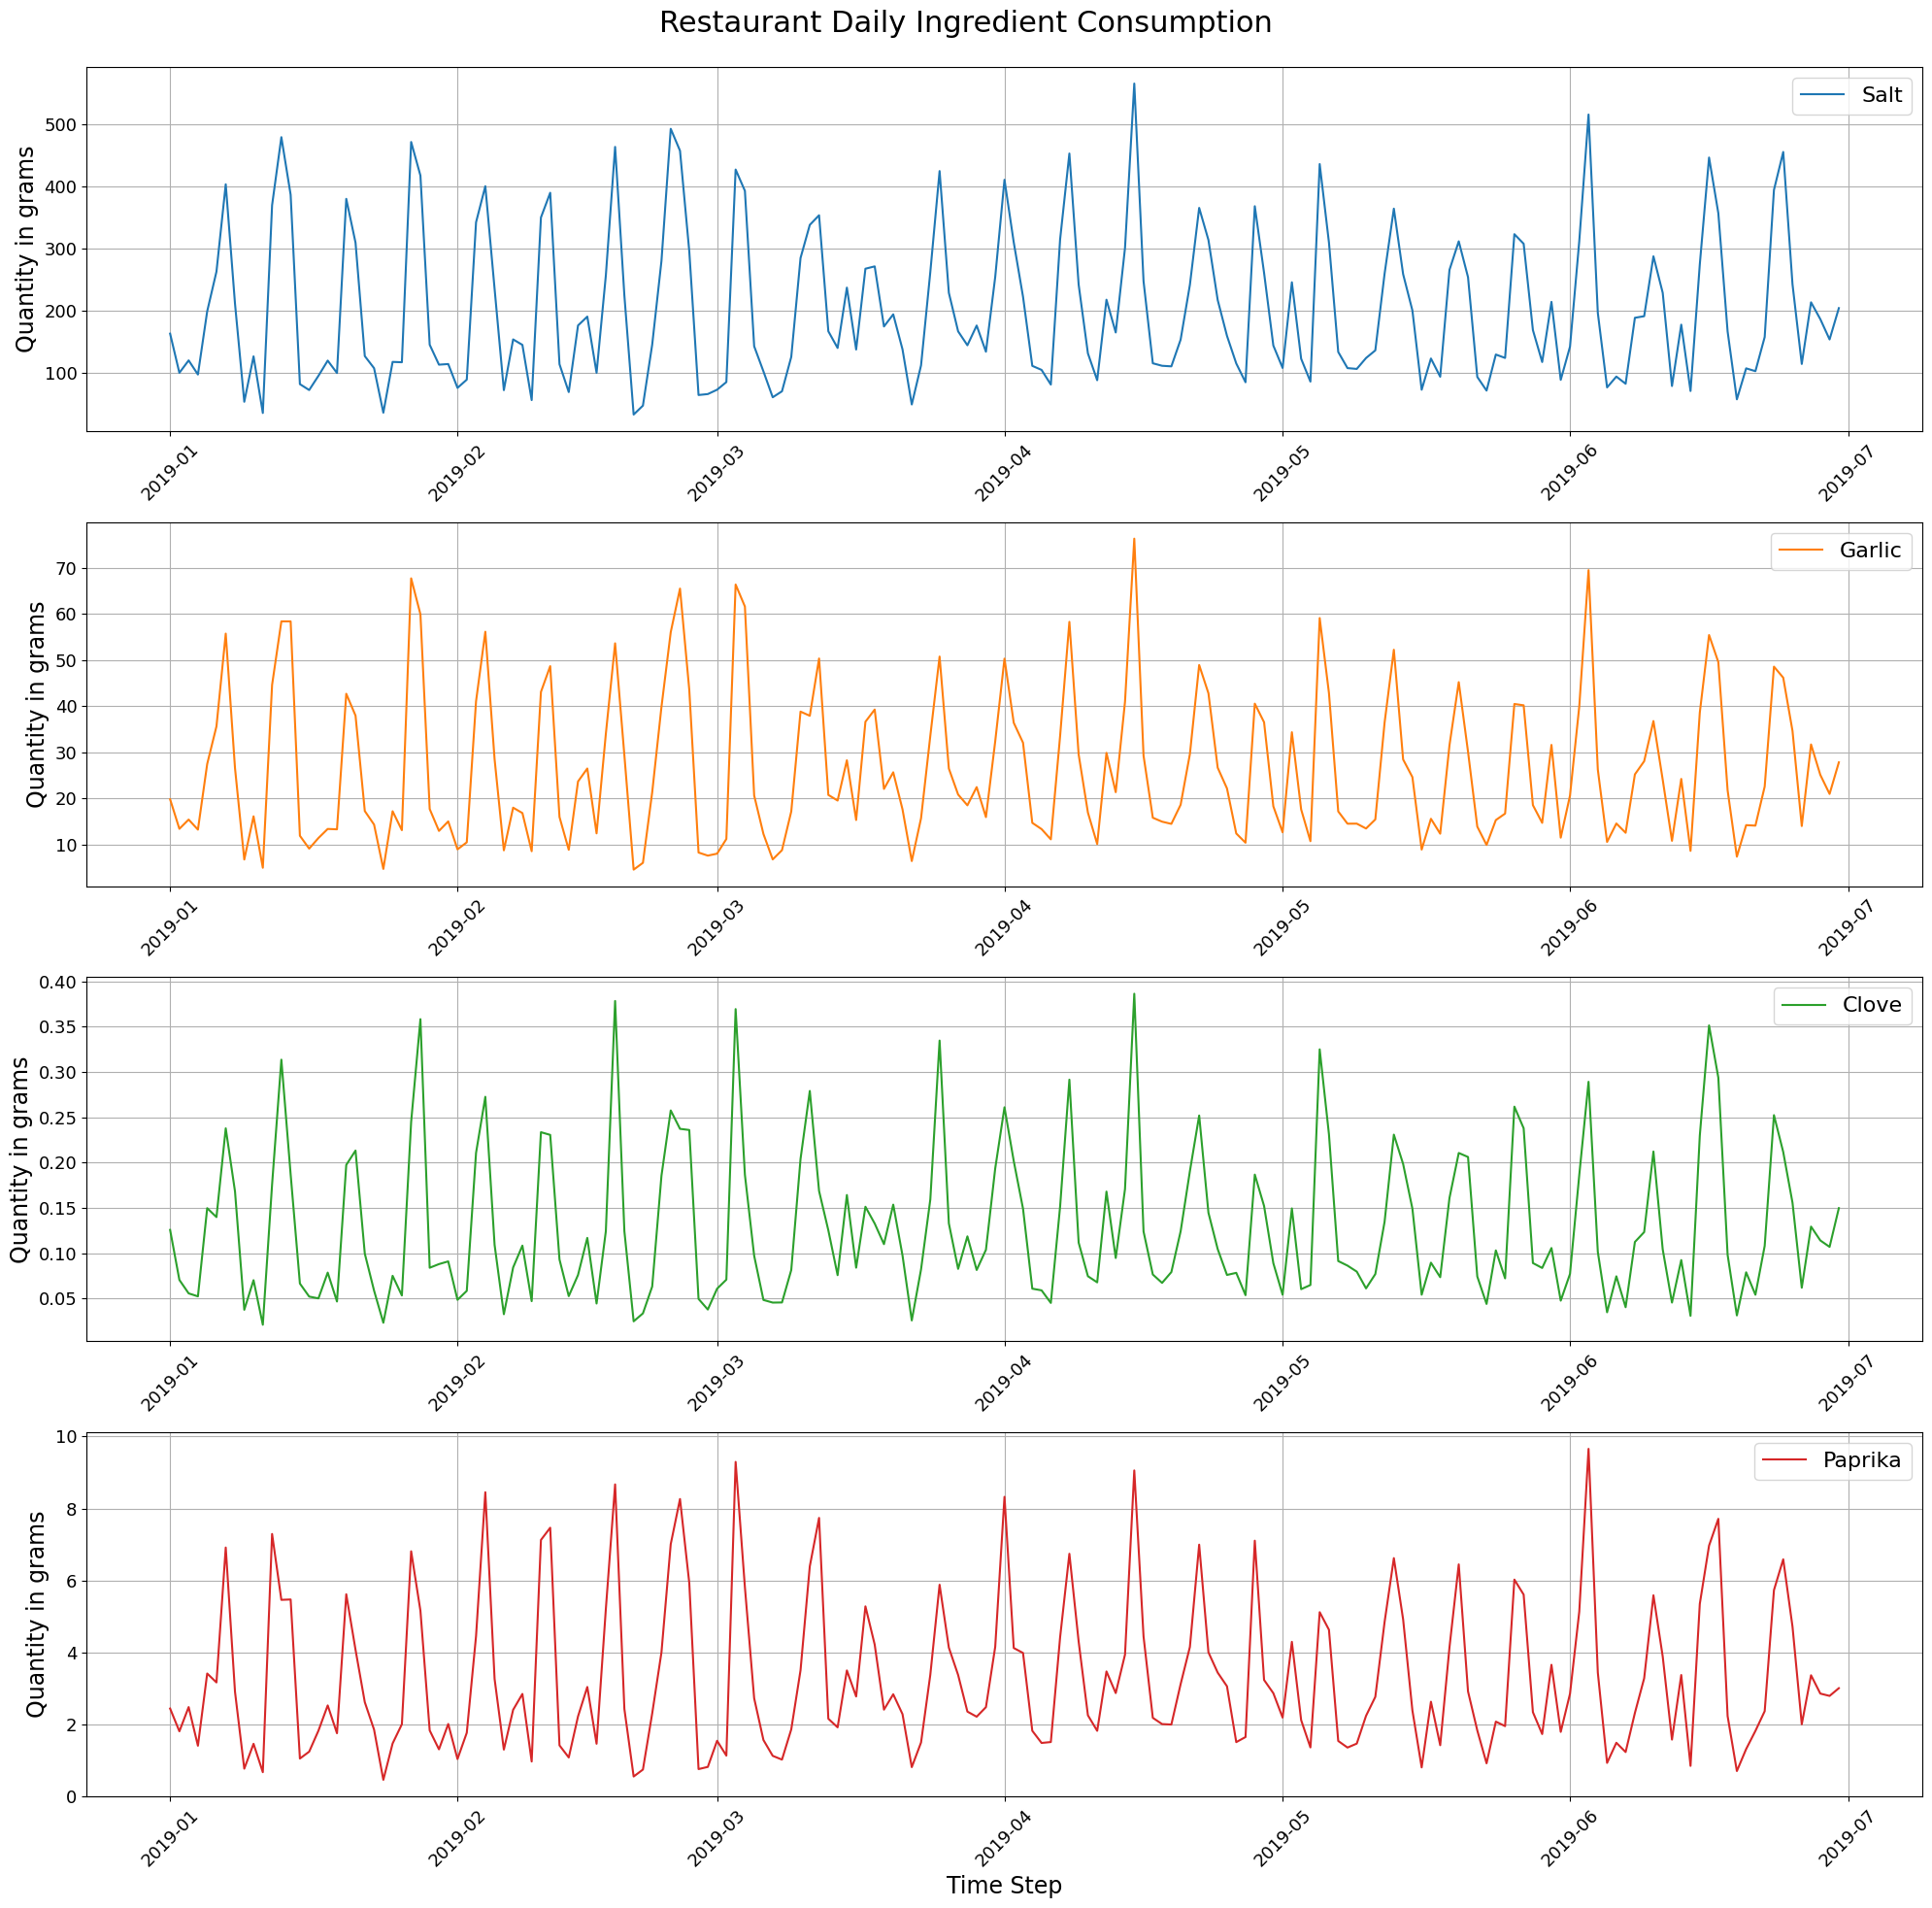

In [14]:
plot_ingrs_daily_consumption(daily_consumption_df, selected_ingredients)